# Buyer-Seller Route Distance and Review Scores

This analysis tests whether the straight-line distance between a seller and a buyer is associated with the customer's review score. It uses averaged city-state geolocation coordinates, matching the approach used by the seller-buyer route map. The analysis unit is one reviewed order.

## Load the data

In [8]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path("../data")
line_items = pd.read_csv(
    DATA_DIR / "smartcommerce_consolidated.csv",
    usecols=[
        "order_id",
        "order_item_id",
        "customer_id",
        "seller_id",
        "price",
        "freight_value",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
    ],
    parse_dates=["order_delivered_customer_date", "order_estimated_delivery_date"],
)

orders = (
    line_items.groupby("order_id", as_index=False)
    .agg(
        customer_id=("customer_id", "first"),
        seller_id=("seller_id", "first"),
        total_item_price=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "size"),
        order_delivered_customer_date=("order_delivered_customer_date", "first"),
        order_estimated_delivery_date=("order_estimated_delivery_date", "first"),
        delivery_days=("delivery_days", "first"),
    )
)
customers = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv",
    usecols=["customer_id", "customer_city", "customer_state"],
)
sellers = pd.read_csv(
    DATA_DIR / "olist_sellers_dataset.csv",
    usecols=["seller_id", "seller_city", "seller_state"],
)
orders = orders.merge(customers, on="customer_id", how="left").merge(
    sellers, on="seller_id", how="left"
)
reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv",
    usecols=["order_id", "review_score"],
)
reviews = reviews.dropna(subset=["review_score"]).groupby(
    "order_id", as_index=False
).agg(review_score=("review_score", "mean"))
geo = pd.read_csv(
    DATA_DIR / "olist_geolocation_dataset.csv",
    usecols=["geolocation_city", "geolocation_state", "geolocation_lat", "geolocation_lng"],
)
print(f"Orders: {len(orders):,} | Reviewed orders: {len(reviews):,}")

Orders: 98,666 | Reviewed orders: 98,673


## Prepare route and delivery features

The route distance is a haversine distance between averaged city-state coordinates. The late-delivery flag compares the actual delivery date with the estimated delivery date.

In [9]:
def city_key(city, state):
    value = unicodedata.normalize("NFKD", f"{city} {state}".casefold())
    value = "".join(character for character in value if not unicodedata.combining(character))
    return re.sub(r"[^a-z0-9]+", " ", value).strip()

geo["city_key"] = [city_key(city, state) for city, state in zip(geo.geolocation_city, geo.geolocation_state)]
coordinates = geo.groupby("city_key", as_index=False).agg(latitude=("geolocation_lat", "mean"), longitude=("geolocation_lng", "mean"))
orders["buyer_city_key"] = [city_key(city, state) for city, state in zip(orders.customer_city, orders.customer_state)]
orders["seller_city_key"] = [city_key(city, state) for city, state in zip(orders.seller_city, orders.seller_state)]
orders = orders.merge(coordinates.rename(columns={"city_key": "buyer_city_key", "latitude": "buyer_latitude", "longitude": "buyer_longitude"}), on="buyer_city_key", how="inner")
orders = orders.merge(coordinates.rename(columns={"city_key": "seller_city_key", "latitude": "seller_latitude", "longitude": "seller_longitude"}), on="seller_city_key", how="inner")

def haversine_km(latitude_1, longitude_1, latitude_2, longitude_2):
    radius_km = 6371.0088
    latitude_1, longitude_1, latitude_2, longitude_2 = map(np.radians, [latitude_1, longitude_1, latitude_2, longitude_2])
    delta_latitude = latitude_2 - latitude_1
    delta_longitude = longitude_2 - longitude_1
    value = np.sin(delta_latitude / 2) ** 2 + np.cos(latitude_1) * np.cos(latitude_2) * np.sin(delta_longitude / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(value))

orders["route_distance_km"] = haversine_km(orders.seller_latitude, orders.seller_longitude, orders.buyer_latitude, orders.buyer_longitude)
analysis = orders.merge(reviews, on="order_id", how="inner").dropna(subset=["route_distance_km", "review_score"])
delivery_dates_available = analysis[
    ["order_delivered_customer_date", "order_estimated_delivery_date"]
].notna().all(axis=1)
analysis["late_delivery"] = pd.Series(pd.NA, index=analysis.index, dtype="boolean")
analysis.loc[delivery_dates_available, "late_delivery"] = (
    analysis.loc[delivery_dates_available, "order_delivered_customer_date"]
    > analysis.loc[delivery_dates_available, "order_estimated_delivery_date"]
)
late_analysis = analysis.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
).copy()
print(f"Reviewed orders with both route coordinates: {len(analysis):,}")
print(f"Reviewed orders with delivery dates: {len(late_analysis):,}")
display(analysis[["route_distance_km", "review_score"]].describe().round(2))
display(
    late_analysis.groupby("late_delivery", as_index=False)
    .agg(orders=("order_id", "size"), mean_review_score=("review_score", "mean"))
)

Reviewed orders with both route coordinates: 96,148
Reviewed orders with delivery dates: 94,112


,route_distance_km,review_score
count,96148.00,96148.00
mean,601.48,4.10
std,597.11,1.33
min,0.00,1.00
25%,183.59,4.00
50%,434.23,5.00
75%,802.49,5.00
max,9474.69,5.00


,late_delivery,orders,mean_review_score
0,False,86587,4.292546
1,True,7525,2.563588


## Route-distance relationship

The hexbin keeps dense areas readable. The red line is an ordinary least-squares trend line. Correlations use the full dataset; only the displayed x-axis is capped at the 99th percentile to reduce outlier distortion.

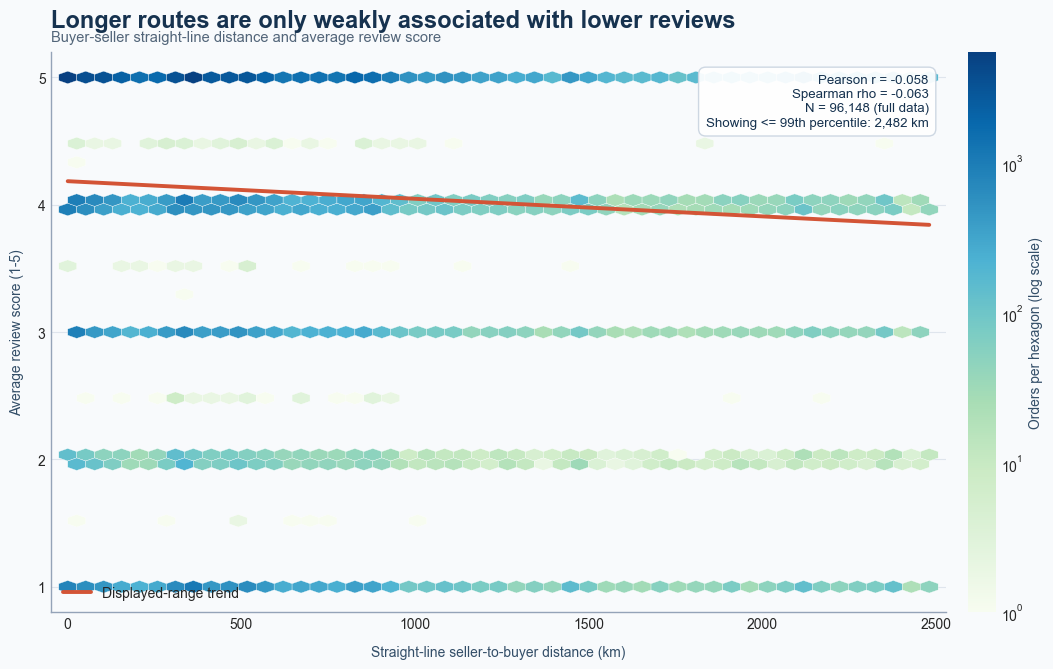

Pearson correlation: -0.058; Spearman correlation: -0.063; displayed-range slope: -0.00014 review points per km


In [5]:
pearson = analysis.route_distance_km.corr(analysis.review_score, method="pearson")
spearman = analysis.route_distance_km.rank().corr(analysis.review_score.rank(), method="pearson")

# Keep the full dataset for statistics, but trim only the visual range to reduce outlier distortion.
display_limit = analysis.route_distance_km.quantile(0.99)
plot_data = analysis[analysis.route_distance_km <= display_limit].copy()
slope, intercept = np.polyfit(plot_data.route_distance_km, plot_data.review_score, 1)
x_line = np.linspace(0, display_limit, 200)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11.5, 6.8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
hexbin = ax.hexbin(
    plot_data.route_distance_km,
    plot_data.review_score,
    gridsize=48,
    mincnt=1,
    bins="log",
    cmap="GnBu",
    linewidths=0.25,
    edgecolors="#ffffff",
)
ax.plot(x_line, intercept + slope * x_line, color="#d35436", linewidth=2.8, label="Displayed-range trend")
ax.set_title("Longer routes are only weakly associated with lower reviews", loc="left", fontsize=17, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Buyer-seller straight-line distance and average review score", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_xlabel("Straight-line seller-to-buyer distance (km)", labelpad=10, color="#334e68")
ax.set_ylabel("Average review score (1-5)", labelpad=10, color="#334e68")
ax.set_xlim(-display_limit * 0.02, display_limit * 1.02)
ax.set_ylim(0.8, 5.2)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(axis="y", color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#94a3b8")
ax.legend(frameon=False, loc="lower left")
colorbar = fig.colorbar(hexbin, ax=ax, pad=0.02)
colorbar.set_label("Orders per hexagon (log scale)", color="#334e68")
colorbar.outline.set_visible(False)
ax.text(
    0.98, 0.96,
    f"Pearson r = {pearson:.3f}\nSpearman rho = {spearman:.3f}\n"
    f"N = {len(analysis):,} (full data)\nShowing <= 99th percentile: {display_limit:,.0f} km",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#16324f",
    bbox={"boxstyle": "round,pad=0.55", "facecolor": "#ffffff", "edgecolor": "#cbd5e1", "alpha": 0.94},
)
fig.tight_layout()
plt.show()
print(f"Pearson correlation: {pearson:.3f}; Spearman correlation: {spearman:.3f}; displayed-range slope: {slope:.5f} review points per km")

## Simpler view: route-distance bands

To make the weak long-route relationship easier to read, route distances are grouped into ten equal-frequency bands. Each point shows the mean review score for one band, with a 95% confidence interval.

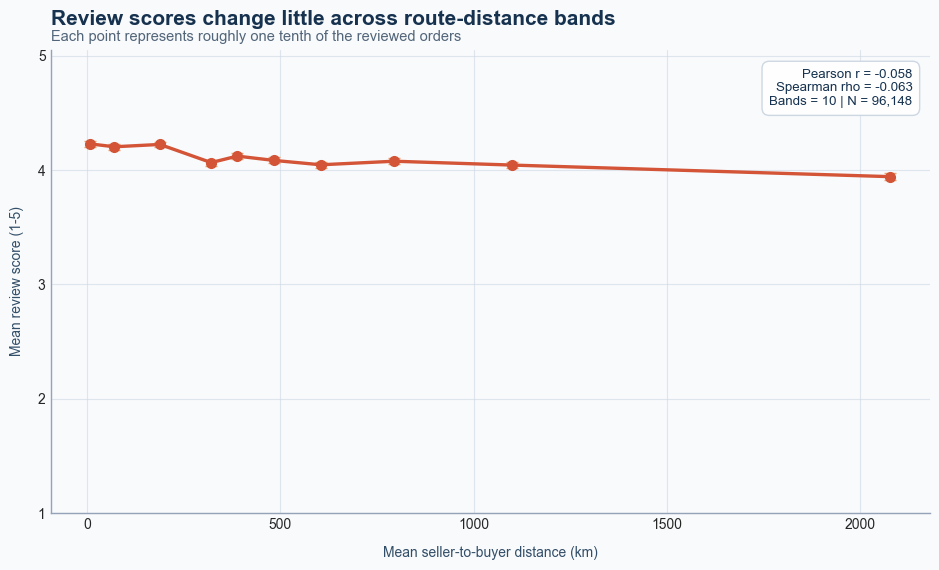

,mean_distance_km,mean_review_score,orders
0,9.345,4.229,9626
1,70.984,4.204,9604
2,188.964,4.224,9615
3,321.497,4.066,10712
4,388.863,4.122,8517
5,482.879,4.085,9615
6,604.980,4.046,9614
7,795.063,4.078,9615
8,1100.263,4.044,9787
9,2077.219,3.943,9443


In [12]:
route_band_data = analysis[["route_distance_km", "review_score"]].dropna().copy()
route_band_data["distance_band"] = pd.qcut(
    route_band_data["route_distance_km"],
    q=10,
    duplicates="drop",
)
route_band_summary = (
    route_band_data.groupby("distance_band", observed=True)
    .agg(
        mean_distance_km=("route_distance_km", "mean"),
        mean_review_score=("review_score", "mean"),
        review_std=("review_score", "std"),
        orders=("review_score", "size"),
    )
    .reset_index(drop=True)
)
route_band_summary["confidence_interval"] = (
    1.96 * route_band_summary["review_std"] / np.sqrt(route_band_summary["orders"])
)

fig, ax = plt.subplots(figsize=(9.5, 5.8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.errorbar(
    route_band_summary["mean_distance_km"],
    route_band_summary["mean_review_score"],
    yerr=route_band_summary["confidence_interval"],
    fmt="o-",
    color="#d35436",
    ecolor="#e9a66d",
    elinewidth=1.8,
    capsize=4,
    markersize=7,
    linewidth=2.4,
)
ax.set_title("Review scores change little across route-distance bands", loc="left", fontsize=15, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Each point represents roughly one tenth of the reviewed orders", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_xlabel("Mean seller-to-buyer distance (km)", labelpad=10, color="#334e68")
ax.set_ylabel("Mean review score (1-5)", labelpad=10, color="#334e68")
ax.set_ylim(1, 5.05)
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#94a3b8")
ax.text(
    0.98, 0.96,
    f"Pearson r = {pearson:.3f}\nSpearman rho = {spearman:.3f}\n"
    f"Bands = {len(route_band_summary)} | N = {len(route_band_data):,}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#16324f",
    bbox={"boxstyle": "round,pad=0.55", "facecolor": "#ffffff", "edgecolor": "#cbd5e1", "alpha": 0.94},
)
fig.tight_layout()
plt.show()
display(route_band_summary[["mean_distance_km", "mean_review_score", "orders"]].round(3))

## Late deliveries and review scores

A late-delivery indicator is correlated with review score, but the comparison is associative rather than causal. Orders without either delivery date are excluded from this section.

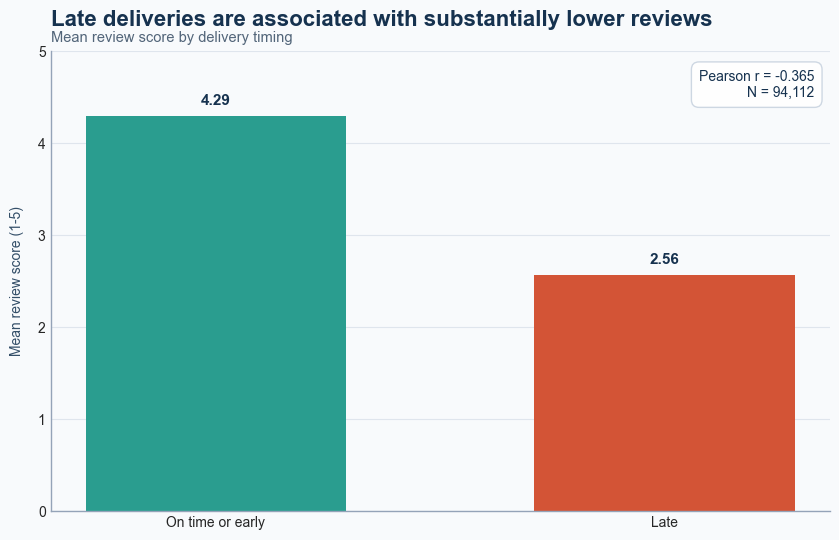

Late-delivery/review-score correlation: -0.365


In [6]:
late_correlation = late_analysis["late_delivery"].astype(int).corr(
    late_analysis["review_score"], method="pearson"
)
late_summary = (
    late_analysis.assign(
        delivery_timing=late_analysis["late_delivery"].map(
            {False: "On time or early", True: "Late"}
        )
    )
    .groupby("delivery_timing", as_index=False)
    .agg(
        orders=("order_id", "size"),
        mean_review_score=("review_score", "mean"),
    )
)
late_summary["delivery_timing"] = pd.Categorical(
    late_summary["delivery_timing"],
    categories=["On time or early", "Late"],
    ordered=True,
)
late_summary = late_summary.sort_values("delivery_timing")

fig, ax = plt.subplots(figsize=(8.5, 5.5), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
bars = ax.bar(
    late_summary["delivery_timing"],
    late_summary["mean_review_score"],
    color=["#2a9d8f", "#d35436"],
    width=0.58,
)
ax.bar_label(
    bars,
    labels=[f"{value:.2f}" for value in late_summary["mean_review_score"]],
    padding=6,
    color="#16324f",
    fontsize=11,
    weight="bold",
)
ax.set_title("Late deliveries are associated with substantially lower reviews", loc="left", fontsize=16, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Mean review score by delivery timing", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_ylabel("Mean review score (1-5)", labelpad=10, color="#334e68")
ax.set_ylim(0, 5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.grid(axis="y", color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#94a3b8")
ax.text(
    0.98, 0.96,
    f"Pearson r = {late_correlation:.3f}\nN = {len(late_analysis):,}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#16324f",
    bbox={"boxstyle": "round,pad=0.55", "facecolor": "#ffffff", "edgecolor": "#cbd5e1", "alpha": 0.94},
)
fig.tight_layout()
plt.show()
print(f"Late-delivery/review-score correlation: {late_correlation:.3f}")

## Feature correlations with review score

This chart compares linear correlations across the available order-level features. Positive values indicate higher review scores as the feature increases; negative values indicate lower review scores. Correlation does not imply causation.

,correlation
Late delivery,-0.365
Delivery days,-0.334
Items per order,-0.116
Total freight value,-0.088
Route distance,-0.058
Total item price,-0.039


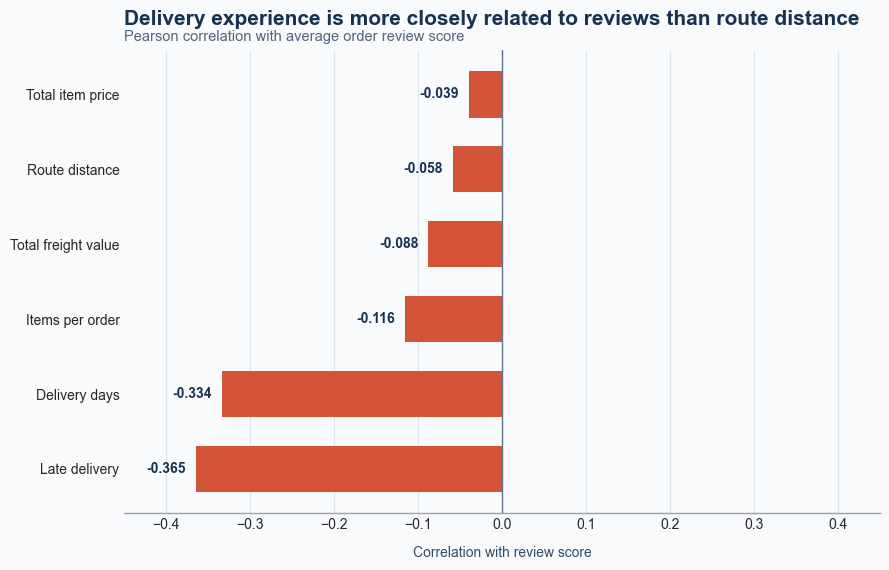

Features with missing values use pairwise complete observations.


In [7]:
feature_data = analysis[
    [
        "route_distance_km",
        "delivery_days",
        "late_delivery",
        "total_item_price",
        "total_freight_value",
        "item_count",
        "review_score",
    ]
].copy()
feature_data["late_delivery"] = feature_data["late_delivery"].astype(float)
feature_correlations = (
    feature_data.corr(numeric_only=True)["review_score"]
    .drop("review_score")
    .sort_values()
)
feature_labels = {
    "route_distance_km": "Route distance",
    "delivery_days": "Delivery days",
    "late_delivery": "Late delivery",
    "total_item_price": "Total item price",
    "total_freight_value": "Total freight value",
    "item_count": "Items per order",
}
feature_correlation_table = feature_correlations.rename(index=feature_labels).rename("correlation").to_frame()
display(feature_correlation_table.round(3))

plot_correlations = feature_correlations.rename(index=feature_labels)
colors = ["#d35436" if value < 0 else "#2a9d8f" for value in plot_correlations]
fig, ax = plt.subplots(figsize=(9, 5.8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.barh(plot_correlations.index, plot_correlations.values, color=colors, height=0.62)
ax.axvline(0, color="#64748b", linewidth=1)
ax.set_title("Delivery experience is more closely related to reviews than route distance", loc="left", fontsize=15, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Pearson correlation with average order review score", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_xlabel("Correlation with review score", labelpad=10, color="#334e68")
ax.set_xlim(-0.45, 0.45)
ax.grid(axis="x", color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#94a3b8")
for index, value in enumerate(plot_correlations.values):
    offset = 0.012 if value >= 0 else -0.012
    alignment = "left" if value >= 0 else "right"
    ax.text(value + offset, index, f"{value:.3f}", va="center", ha=alignment, color="#16324f", fontsize=10, weight="bold")
fig.tight_layout()
plt.show()
print("Features with missing values use pairwise complete observations.")

## Delivery delay and freight value

This exploratory plot tests whether orders with higher freight charges also experience larger delivery delays. Delivery delay is calculated as actual delivery date minus estimated delivery date, so negative values indicate early delivery and positive values indicate lateness. Correlation does not imply causation.

Orders with delivery delay and freight data: 94,112
Freight-value/delivery-delay correlation: -0.051


,delivery_delay_days,total_freight_value
count,94112.00,94112.00
mean,-11.23,22.74
std,10.12,21.49
min,-146.02,0.00
25%,-16.26,13.83
50%,-11.99,17.15
75%,-6.41,23.99
max,188.98,1794.96


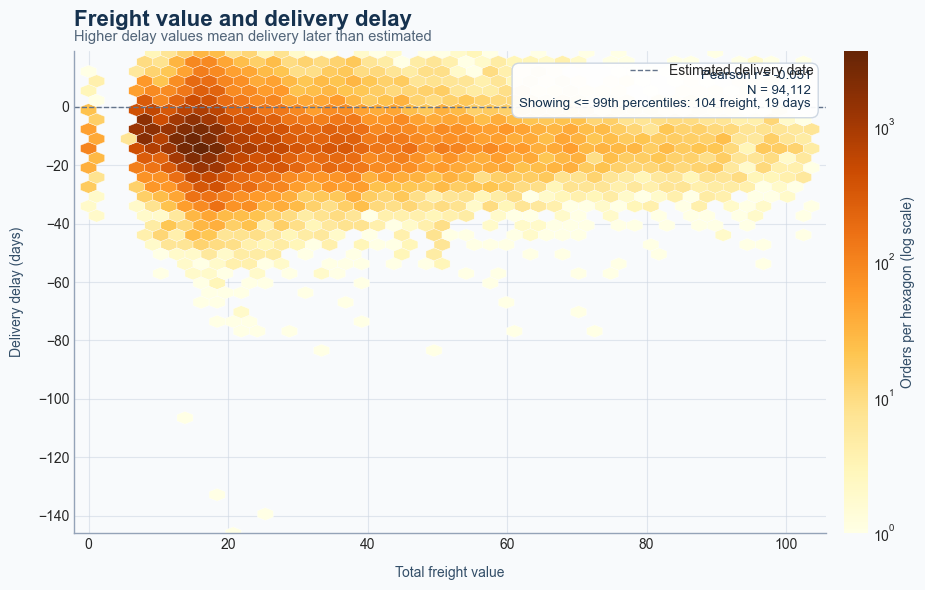

In [10]:
delay_data = analysis[
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "total_freight_value",
    ]
].dropna().copy()
delay_data["delivery_delay_days"] = (
    delay_data["order_delivered_customer_date"]
    - delay_data["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

freight_delay_correlation = delay_data["delivery_delay_days"].corr(
    delay_data["total_freight_value"], method="pearson"
)
print(f"Orders with delivery delay and freight data: {len(delay_data):,}")
print(f"Freight-value/delivery-delay correlation: {freight_delay_correlation:.3f}")
display(
    delay_data[["delivery_delay_days", "total_freight_value"]]
    .describe()
    .round(2)
)

# Cap only the displayed axes at the 99th percentile so outliers do not flatten the plot.
delay_limit = delay_data["delivery_delay_days"].quantile(0.99)
freight_limit = delay_data["total_freight_value"].quantile(0.99)
plot_delay_data = delay_data[
    (delay_data["delivery_delay_days"] <= delay_limit)
    & (delay_data["total_freight_value"] <= freight_limit)
]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
hexbin = ax.hexbin(
    plot_delay_data["total_freight_value"],
    plot_delay_data["delivery_delay_days"],
    gridsize=45,
    mincnt=1,
    bins="log",
    cmap="YlOrBr",
    linewidths=0.25,
    edgecolors="#ffffff",
)
ax.axhline(0, color="#64748b", linewidth=1, linestyle="--", label="Estimated delivery date")
ax.set_title("Freight value and delivery delay", loc="left", fontsize=16, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Higher delay values mean delivery later than estimated", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_xlabel("Total freight value", labelpad=10, color="#334e68")
ax.set_ylabel("Delivery delay (days)", labelpad=10, color="#334e68")
ax.set_xlim(-freight_limit * 0.02, freight_limit * 1.02)
ax.set_ylim(min(plot_delay_data["delivery_delay_days"].min(), -1), delay_limit * 1.02)
ax.grid(color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#94a3b8")
ax.legend(frameon=False, loc="upper right")
colorbar = fig.colorbar(hexbin, ax=ax, pad=0.02)
colorbar.set_label("Orders per hexagon (log scale)", color="#334e68")
colorbar.outline.set_visible(False)
ax.text(
    0.98, 0.96,
    f"Pearson r = {freight_delay_correlation:.3f}\nN = {len(delay_data):,}\n"
    f"Showing <= 99th percentiles: {freight_limit:.0f} freight, {delay_limit:.0f} days",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#16324f",
    bbox={"boxstyle": "round,pad=0.55", "facecolor": "#ffffff", "edgecolor": "#cbd5e1", "alpha": 0.94},
)
fig.tight_layout()
plt.show()

## Simpler view: binned freight values

To make the weak relationship easier to read, freight values are grouped into ten equal-frequency bands. Each point shows the mean delivery delay for one band; the vertical line shows the 95% confidence interval around that mean.

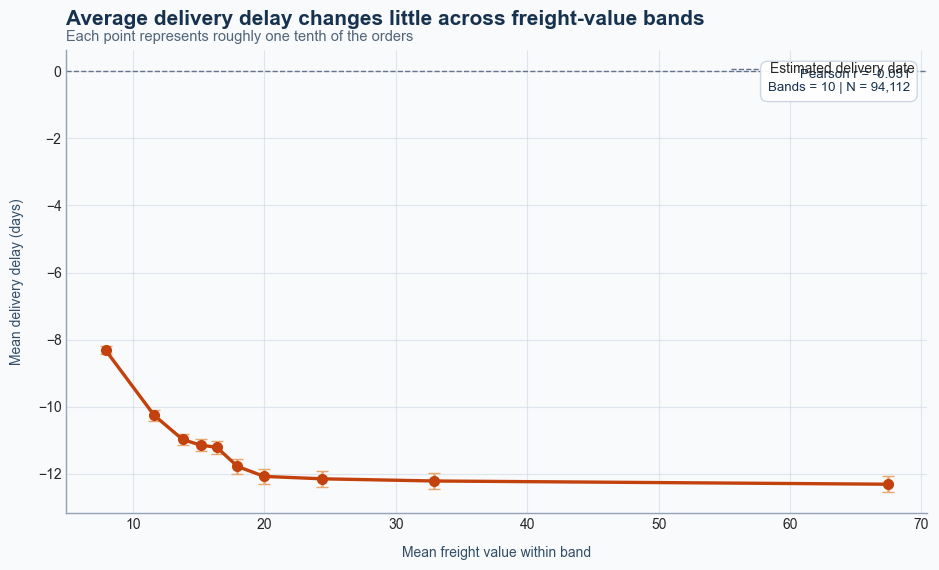

,mean_freight,mean_delay,orders
0,7.91,-8.31,9685
1,11.61,-10.25,9160
2,13.77,-10.97,9509
3,15.14,-11.14,9298
4,16.37,-11.21,9415
5,17.95,-11.78,9437
6,19.98,-12.07,9406
7,24.41,-12.14,9383
8,32.93,-12.21,9410
9,67.45,-12.30,9409


In [11]:
binned_delay_data = delay_data.copy()
binned_delay_data["freight_band"] = pd.qcut(
    binned_delay_data["total_freight_value"],
    q=10,
    duplicates="drop",
)
binned_delay_summary = (
    binned_delay_data.groupby("freight_band", observed=True)
    .agg(
        mean_freight=("total_freight_value", "mean"),
        mean_delay=("delivery_delay_days", "mean"),
        delay_std=("delivery_delay_days", "std"),
        orders=("delivery_delay_days", "size"),
    )
    .reset_index(drop=True)
)
binned_delay_summary["confidence_interval"] = (
    1.96 * binned_delay_summary["delay_std"] / np.sqrt(binned_delay_summary["orders"])
)

fig, ax = plt.subplots(figsize=(9.5, 5.8), facecolor="#f8fafc")
ax.set_facecolor("#f8fafc")
ax.errorbar(
    binned_delay_summary["mean_freight"],
    binned_delay_summary["mean_delay"],
    yerr=binned_delay_summary["confidence_interval"],
    fmt="o-",
    color="#c2410c",
    ecolor="#e9a66d",
    elinewidth=1.8,
    capsize=4,
    markersize=7,
    linewidth=2.4,
)
ax.axhline(0, color="#64748b", linewidth=1, linestyle="--", label="Estimated delivery date")
ax.set_title("Average delivery delay changes little across freight-value bands", loc="left", fontsize=15, weight="bold", color="#16324f", pad=18)
ax.text(0, 1.02, "Each point represents roughly one tenth of the orders", transform=ax.transAxes, fontsize=10.5, color="#526579")
ax.set_xlabel("Mean freight value within band", labelpad=10, color="#334e68")
ax.set_ylabel("Mean delivery delay (days)", labelpad=10, color="#334e68")
ax.grid(color="#cbd5e1", linewidth=0.8, alpha=0.55)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#94a3b8")
ax.legend(frameon=False, loc="upper right")
ax.text(
    0.98, 0.96,
    f"Pearson r = {freight_delay_correlation:.3f}\n"
    f"Bands = {len(binned_delay_summary)} | N = {len(delay_data):,}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#16324f",
    bbox={"boxstyle": "round,pad=0.55", "facecolor": "#ffffff", "edgecolor": "#cbd5e1", "alpha": 0.94},
)
fig.tight_layout()
plt.show()
display(binned_delay_summary[["mean_freight", "mean_delay", "orders"]].round(2))

## Interpretation

A correlation near zero would indicate that route distance alone is a weak linear or monotonic predictor of review score. It would not prove that distance has no effect, because delivery time, delays, product category, seller performance, and customer expectations may also influence reviews.